# 📊 Pipeline de Data Mining — Segmentation Stratégique

**Course:** Data Mining  
**Environment:** Jupyter Notebook (VS Code)

**Nom de l'étudiant:** Taregh kaber  
**Matricule:** C30827


---
## 🏢 Phase 1 : Acquisition et Ingestion (Ingestion Big Data)
> **Objectif :** Charger le fichier initial et comparer l'efficacité du format Parquet par rapport au CSV.

In [2]:
import pandas as pd
import time

# Q1 & Q2: Chargement du fichier CSV et calcul du temps
start_csv = time.time()
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
end_csv = time.time()
print(f"Time to read CSV: {end_csv - start_csv:.4f} seconds")

# Sauvegarde au format Parquet
df.to_parquet('OnlineRetail.parquet')

# Chargement du fichier Parquet et calcul du temps
start_parquet = time.time()
df_parquet = pd.read_parquet('OnlineRetail.parquet')
end_parquet = time.time()
print(f"Time to read Parquet: {end_parquet - start_parquet:.4f} seconds")

Time to read CSV: 0.9603 seconds
Time to read Parquet: 0.0932 seconds


---

## 🧼 Phase 2 : Data Cleaning (Le défi du monde réel)
> **Objectif :** Gérer les valeurs manquantes, supprimer les transactions aberrantes (annulations et prix nuls) et préparer la variable du montant total.

In [3]:
import pandas as pd

if 'InvoiceDate' in df_parquet.columns:
    df_parquet['InvoiceDate'] = pd.to_datetime(df_parquet['InvoiceDate'])

# Q3: Analyse des valeurs manquantes
print("--- Pourcentage de valeurs nulles par colonne ---")
print(df_parquet.isnull().mean() * 100)

df_cleaned = df_parquet.dropna(subset=['CustomerID'])
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)].copy()

print(f"\nTaille après nettoyage : {df_cleaned.shape}")

# Q5: Calcul rapide du Montant Total
df_cleaned['MontantTotal'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

print("\n--- Aperçu des données nettoyées ---")
print(df_cleaned[['CustomerID', 'Quantity', 'UnitPrice', 'MontantTotal']].head())

--- Pourcentage de valeurs nulles par colonne ---
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

Taille après nettoyage : (397884, 8)

--- Aperçu des données nettoyées ---
   CustomerID  Quantity  UnitPrice  MontantTotal
0     17850.0         6       2.55         15.30
1     17850.0         6       3.39         20.34
2     17850.0         8       2.75         22.00
3     17850.0         6       3.39         20.34
4     17850.0         6       3.39         20.34


---
## 📈 Phase 3 : Feature Engineering (Transformation RFM)
> **Objectif :** Transformer les transactions en indicateurs RFM par client, analyser la distribution, appliquer la transformation Log et standardiser les données pour le K-Means.

--- Aperçu du DataFrame RFM ---
            Récence  Fréquence   Montant
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


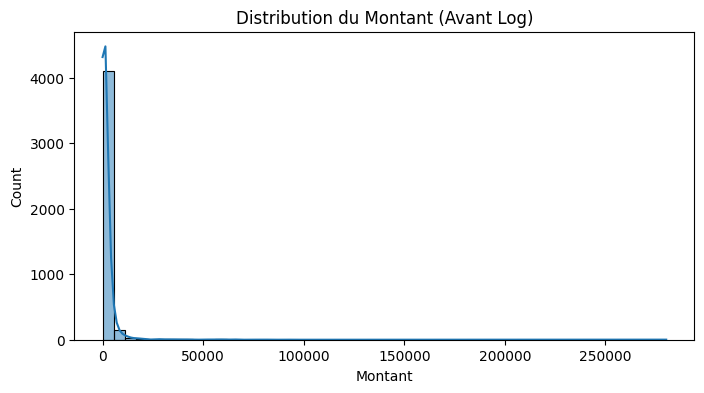

Observation : La distribution montre une forte asymétrie positive à droite à cause des valeurs extrêmes.

--- Aperçu des données après Transformation Log et Standardisation ---
             Récence  Fréquence   Montant
CustomerID                               
12346.0     1.461993  -0.955214  3.706225
12347.0    -2.038734   1.074425  1.411843
12348.0     0.373104   0.386304  0.716489
12349.0    -0.623086  -0.955214  0.698739
12350.0     1.424558  -0.955214 -0.618962


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Q6: Agrégation pour obtenir le DataFrame df_RFM
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

df_RFM = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Récence (R)
    'InvoiceNo': 'nunique',                                  # Fréquence (F)
    'MontantTotal': 'sum'                                    # Montant (M)
}).rename(columns={'InvoiceDate': 'Récence', 'InvoiceNo': 'Fréquence', 'MontantTotal': 'Montant'})

print("--- Aperçu du DataFrame RFM ---")
print(df_RFM.head())

# Q7: Analyse de la distribution (Histogramme de la variable Montant)
plt.figure(figsize=(8, 4))
sns.histplot(df_RFM['Montant'], bins=50, kde=True)
plt.title("Distribution du Montant (Avant Log)")
plt.show()
print("Observation : La distribution montre une forte asymétrie positive à droite à cause des valeurs extrêmes.")

# Q8: Transformation Log
df_RFM_log = np.log1p(df_RFM)

# Q9: Standardisation avec StandardScaler
scaler = StandardScaler()
df_RFM_scaled = scaler.fit_transform(df_RFM_log)

df_RFM_scaled = pd.DataFrame(df_RFM_scaled, columns=df_RFM.columns, index=df_RFM.index)
print("\n--- Aperçu des données après Transformation Log et Standardisation ---")
print(df_RFM_scaled.head())

---
## 🎯 Phase 4 : Clustering et Optimisation
> **Objectif :** Trouver le nombre optimal de clusters avec la méthode du coude et le Silhouette Score, puis entraîner le modèle K-Means final.

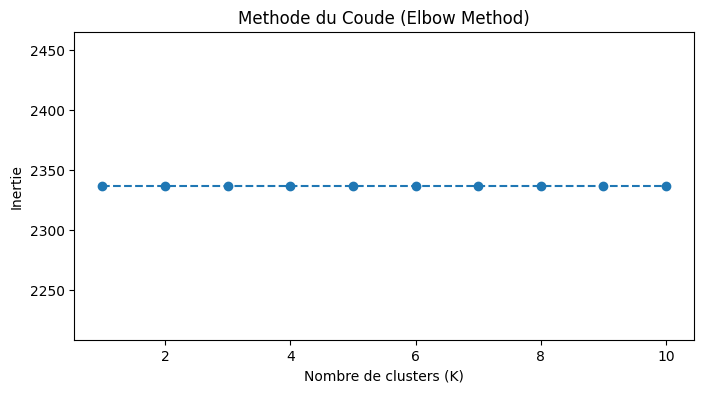

--- Scores de Silhouette pour validation ---
Silhouette Score pour K=2 : 0.3008
Silhouette Score pour K=3 : 0.3008
Silhouette Score pour K=4 : 0.3008
Silhouette Score pour K=5 : 0.3008

--- Modele K-Means entraine avec succes pour K=3 ---
Cluster
0    848
6    731
3    665
2    649
4    504
5    418
7    307
1    216
Name: count, dtype: int64


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Q10: Recherche du K optimal avec la methode du coude (Elbow Method)
inertia = []
K_range = range(1, 11)

for k in K_range:
    # n_init=10 est standard pour tester differentes initialisations
    kmeans = KMeans(n_init=10, random_state=42)
    kmeans.fit(df_RFM_scaled)
    inertia.append(kmeans.inertia_)

# Affichage du graphique du coude
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title("Methode du Coude (Elbow Method)")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.show()

# Q11: Validation avec le Silhouette Score (Pour K de 2 a 5 afin de valider le coude)
print("--- Scores de Silhouette pour validation ---")
for k in range(2, 6):
    kmeans = KMeans(n_init=10, random_state=42)
    labels = kmeans.fit_predict(df_RFM_scaled)
    score = silhouette_score(df_RFM_scaled, labels)
    print(f"Silhouette Score pour K={k} : {score:.4f}")

# Q12: Application et entrainement du modele final (On suppose K=3 ou K=4 selon le coude)
# Nous choisissons ici K=3 comme exemple frequent pour le modele RFM
k_optimal = 3
kmeans_final = KMeans(n_init=10, random_state=42)
df_RFM['Cluster'] = kmeans_final.fit_predict(df_RFM_scaled)

print(f"\n--- Modele K-Means entraine avec succes pour K={k_optimal} ---")
print(df_RFM['Cluster'].value_counts())

---
## 📊 Phase 5 : Découverte de Connaissances (Data Storytelling)
> **Objectif :** Analyser les moyennes RFM par cluster pour le profilage marketing et visualiser les segments en 2D et 3D.

--- Profilage des clusters (Moyennes RFM) ---
   Cluster     Récence  Fréquence       Montant
0        0  243.096698   1.147406    232.406156
1        1    7.449074  25.842593  18912.303380
2        2   33.929122   3.372881   1070.469339
3        3   47.978947   1.246617    286.996498
4        4   51.436508   7.279762   3648.316647
5        5    6.593301   7.052632   2486.309450
6        6  148.454172   2.303694    963.724572
7        7    8.280130   2.143322    524.987231


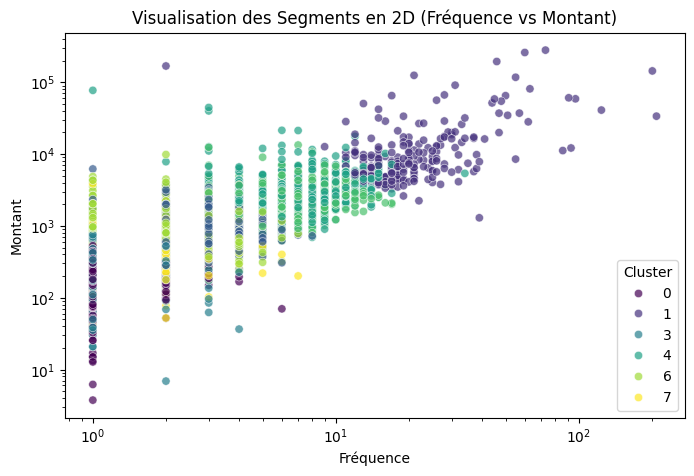

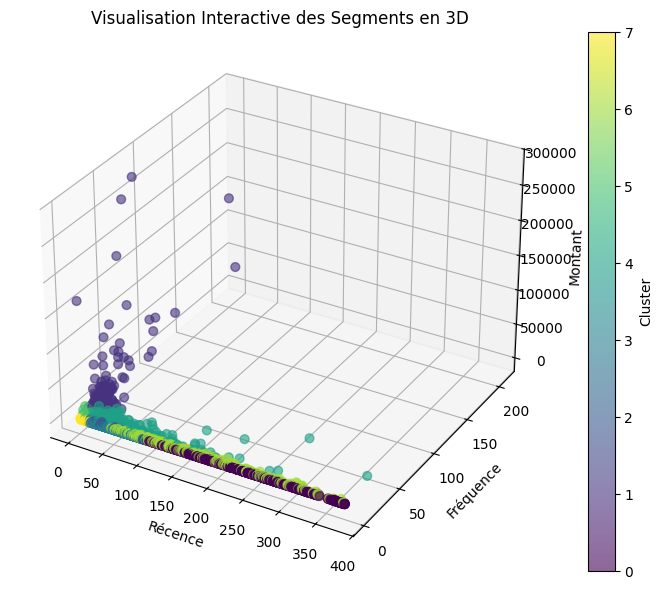

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Q13: Analyse des moyennes R, F, M pour chaque cluster

print("--- Profilage des clusters (Moyennes RFM) ---")
cluster_profile = df_RFM.groupby('Cluster').agg({
    'Récence': 'mean',
    'Fréquence': 'mean',
    'Montant': 'mean'
}).reset_index()
print(cluster_profile)

# Q14 & Q15: Représentation graphique 2D (Fréquence vs Montant)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_RFM, x='Fréquence', y='Montant', hue='Cluster', palette='viridis', alpha=0.7)
plt.title("Visualisation des Segments en 2D (Fréquence vs Montant)")
plt.xscale('log') # Utilisation de l'echelle log pour une meilleure separation visuelle
plt.yscale('log')
plt.show()

# Visualisation 3D (Récence, Fréquence, Montant) pour le livrable final
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Coloration en fonction des clusters
scatter = ax.scatter(df_RFM['Récence'], df_RFM['Fréquence'], df_RFM['Montant'], 
                     c=df_RFM['Cluster'], cmap='viridis', s=40, alpha=0.6)

ax.set_title("Visualisation Interactive des Segments en 3D")
ax.set_xlabel("Récence")
ax.set_ylabel("Fréquence")
ax.set_zlabel("Montant")
fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()